# Feature Engineering & Preprocessing Pipeline

**Goal:** Build a robust, leak-free scikit-learn preprocessing pipeline that performs feature encoding, scaling, missing-value imputation, and correlation/feature-importance analysis — structured so it is reusable on any tabular dataset with numeric + categorical columns.

**Dataset:** Titanic passenger data (binary classification: `Survived` 0/1). It stands in for the suggested "Credit Default Risk / Medical Diagnostics" style problems in this task: mixed numeric + categorical features, real missing values, and a binary target — the same preprocessing challenges apply regardless of domain.

**Leakage discipline followed throughout:**
- Train/test split happens **before** any imputation, scaling, or encoding is fit.
- All transformers (imputers, scalers, encoders) are `fit` only on the training set and applied (`transform`) to the test set — enforced structurally by wrapping everything in a single `sklearn.pipeline.Pipeline` / `ColumnTransformer`, never by fitting on the full dataset "for convenience."
- Feature importance and correlation analysis are computed on the **training set only**, so no test-set information leaks into feature-selection decisions.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import mutual_info_classif
from sklearn.metrics import classification_report, roc_auc_score

import category_encoders as ce

RANDOM_STATE = 42
pd.set_option('display.max_columns', None)

## 1. Load the data

In [2]:
df = pd.read_csv("titanic.csv")
print(df.shape)
df.head()

(891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
df.info()
print("\nMissing values per column:\n", df.isnull().sum())

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB

Missing values per column:
 PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dt

**Observations:**
- `Age` (~20% missing) and `Embarked` (2 missing) need imputation; `Cabin` is missing on ~77% of rows — too sparse to impute meaningfully, so it is dropped rather than imputed (imputing a 77%-missing column would mostly be inventing data).
- `PassengerId`, `Name`, `Ticket` are identifiers / free text with effectively one distinct value per row — not usable as-is by a tabular model and dropped (a real project might engineer a `Title` feature from `Name`, noted as a follow-up, not required here).
- Remaining features split cleanly into **numeric** (`Age`, `SibSp`, `Parch`, `Fare`) and **categorical** (`Pclass`, `Sex`, `Embarked`). `Pclass` is technically an ordinal integer but is treated as categorical here since class 1/2/3 is a label, not a magnitude.

## 2. Train/test split — before any transformation

In [4]:
target = "Survived"
drop_cols = ["PassengerId", "Name", "Ticket", "Cabin"]

X = df.drop(columns=drop_cols + [target])
y = df[target]

numeric_features = ["Age", "SibSp", "Parch", "Fare"]
categorical_features = ["Pclass", "Sex", "Embarked"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print("Train shape:", X_train.shape, " Test shape:", X_test.shape)
print("Train churn/survival rate:", y_train.mean().round(3), " Test rate:", y_test.mean().round(3))

Train shape: (712, 7)  Test shape: (179, 7)
Train churn/survival rate: 0.383  Test rate: 0.385


**Why the split happens here, first:** every imputer/scaler/encoder fit below only ever sees `X_train`/`y_train`. If we had instead imputed missing `Age` values or fit the scaler on the full `df` and split afterward, statistics from the test set (its mean, its category frequencies, its Age distribution) would leak into training — producing an optimistic, unrealistic performance estimate.

## 3. Reusable preprocessing pipeline

Two versions of the categorical branch are built to demonstrate both encoding strategies named in the task:
- **One-Hot Encoding** — safe default for low-cardinality categoricals with no ordinal meaning.
- **Target Encoding** — replaces each category with a (regularized) mean of the target for that category; more compact for high-cardinality columns, but leakage-prone if not fit strictly on the training fold, so `category_encoders.TargetEncoder` is fit only on `(X_train, y_train)`.

In [5]:
def build_preprocessor(numeric_features, categorical_features, categorical_encoding="onehot"):
    """Reusable ColumnTransformer factory.

    Parameters
    ----------
    numeric_features : list[str]
    categorical_features : list[str]
    categorical_encoding : {"onehot", "target"}

    Returns
    -------
    sklearn.compose.ColumnTransformer, fit only via Pipeline.fit(X_train, y_train)
    """
    numeric_pipeline = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ])

    if categorical_encoding == "onehot":
        categorical_pipeline = Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("encoder", OneHotEncoder(handle_unknown="ignore")),
        ])
    elif categorical_encoding == "target":
        categorical_pipeline = Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("encoder", ce.TargetEncoder()),
        ])
    else:
        raise ValueError("categorical_encoding must be 'onehot' or 'target'")

    preprocessor = ColumnTransformer(transformers=[
        ("num", numeric_pipeline, numeric_features),
        ("cat", categorical_pipeline, categorical_features),
    ])
    return preprocessor

## 4. Full pipeline: preprocessing + model (One-Hot variant)

In [6]:
onehot_pipeline = Pipeline(steps=[
    ("preprocessor", build_preprocessor(numeric_features, categorical_features, "onehot")),
    ("classifier", RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE)),
])

# A single .fit call: imputers, scaler, encoder, and model are ALL fit on training data only.
onehot_pipeline.fit(X_train, y_train)

pred = onehot_pipeline.predict(X_test)
proba = onehot_pipeline.predict_proba(X_test)[:, 1]

print(classification_report(y_test, pred, target_names=["did not survive", "survived"]))
print("ROC-AUC:", round(roc_auc_score(y_test, proba), 3))

                 precision    recall  f1-score   support

did not survive       0.82      0.90      0.86       110
       survived       0.81      0.68      0.74        69

       accuracy                           0.82       179
      macro avg       0.81      0.79      0.80       179
   weighted avg       0.82      0.82      0.81       179

ROC-AUC: 0.832


## 5. Full pipeline: preprocessing + model (Target Encoding variant)

In [7]:
target_pipeline = Pipeline(steps=[
    ("preprocessor", build_preprocessor(numeric_features, categorical_features, "target")),
    ("classifier", RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE)),
])

target_pipeline.fit(X_train, y_train)

pred_te = target_pipeline.predict(X_test)
proba_te = target_pipeline.predict_proba(X_test)[:, 1]

print(classification_report(y_test, pred_te, target_names=["did not survive", "survived"]))
print("ROC-AUC:", round(roc_auc_score(y_test, proba_te), 3))

                 precision    recall  f1-score   support

did not survive       0.82      0.87      0.85       110
       survived       0.77      0.70      0.73        69

       accuracy                           0.80       179
      macro avg       0.80      0.78      0.79       179
   weighted avg       0.80      0.80      0.80       179

ROC-AUC: 0.832


**Note on comparing the two:** both variants are shown for completeness. On a small, low-cardinality categorical set like this one, one-hot encoding is generally the safer default (no leakage risk, fully interpretable). Target encoding earns its complexity on high-cardinality columns (e.g., ZIP code, merchant ID) where one-hot would explode the feature space — worth remembering when adapting this pipeline to the Credit Default Risk / Medical Diagnostics style datasets referenced in the task.

## 6. Correlation analysis (training set only)

In [8]:
train_numeric = X_train[numeric_features].copy()
train_numeric["Survived"] = y_train.values

corr = train_numeric.corr(numeric_only=True)
corr

,Age,SibSp,Parch,Fare,Survived
Age,1.000000,-0.312885,-0.175573,0.106915,-0.084268
SibSp,-0.312885,1.000000,0.392269,0.127011,-0.026115
Parch,-0.175573,0.392269,1.000000,0.177235,0.084178
Fare,0.106915,0.127011,0.177235,1.000000,0.275499
Survived,-0.084268,-0.026115,0.084178,0.275499,1.000000


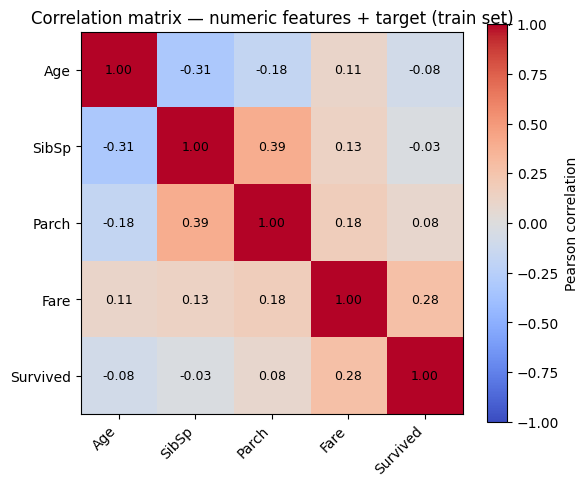

In [9]:
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=45, ha="right")
ax.set_yticklabels(corr.columns)
for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", color="black", fontsize=9)
fig.colorbar(im, ax=ax, label="Pearson correlation")
ax.set_title("Correlation matrix — numeric features + target (train set)")
plt.tight_layout()
plt.show()

**Reading the matrix:** `Fare` has the strongest (positive) linear relationship with survival among the numeric features; `SibSp`/`Parch` are mildly correlated with each other (both describe family aboard), which is worth flagging for a linear model (multicollinearity) even though it's less of a concern for the tree-based model used here.

## 7. Feature importance: mutual information (train set)

In [10]:
# Mutual information needs a fully numeric, non-null matrix -> reuse the fitted preprocessor
# from the one-hot pipeline, but only ever transform, never re-fit, X_train here.
preprocessor_fitted = onehot_pipeline.named_steps["preprocessor"]
X_train_transformed = preprocessor_fitted.transform(X_train)

# Recover human-readable feature names after one-hot encoding
ohe = preprocessor_fitted.named_transformers_["cat"].named_steps["encoder"]
cat_feature_names = ohe.get_feature_names_out(categorical_features)
all_feature_names = numeric_features + list(cat_feature_names)

mi_scores = mutual_info_classif(X_train_transformed, y_train, random_state=RANDOM_STATE)
mi_series = pd.Series(mi_scores, index=all_feature_names).sort_values(ascending=False)
mi_series

Fare          0.169839
Sex_female    0.157226
Sex_male      0.141564
Pclass_3      0.046828
Pclass_1      0.038747
Embarked_S    0.033799
Embarked_Q    0.029533
Age           0.025150
Embarked_C    0.012170
SibSp         0.008901
Pclass_2      0.004183
Parch         0.000000
dtype: float64

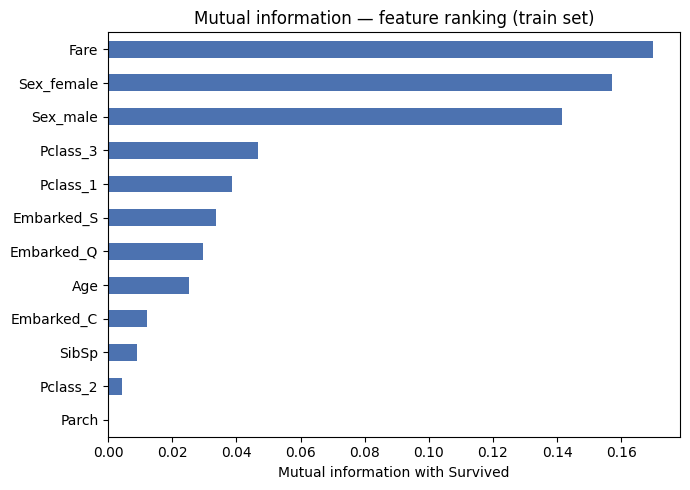

In [11]:
fig, ax = plt.subplots(figsize=(7, 5))
mi_series.plot(kind="barh", ax=ax, color="#4C72B0")
ax.invert_yaxis()
ax.set_xlabel("Mutual information with Survived")
ax.set_title("Mutual information — feature ranking (train set)")
plt.tight_layout()
plt.show()

## 8. Feature importance: tree-based (Random Forest, train set)

In [12]:
rf = onehot_pipeline.named_steps["classifier"]
rf_importances = pd.Series(rf.feature_importances_, index=all_feature_names).sort_values(ascending=False)
rf_importances

Fare          0.253140
Age           0.244620
Sex_male      0.152099
Sex_female    0.131715
Pclass_3      0.051039
SibSp         0.045060
Parch         0.037933
Pclass_1      0.031169
Embarked_S    0.017355
Pclass_2      0.017128
Embarked_C    0.011798
Embarked_Q    0.006944
dtype: float64

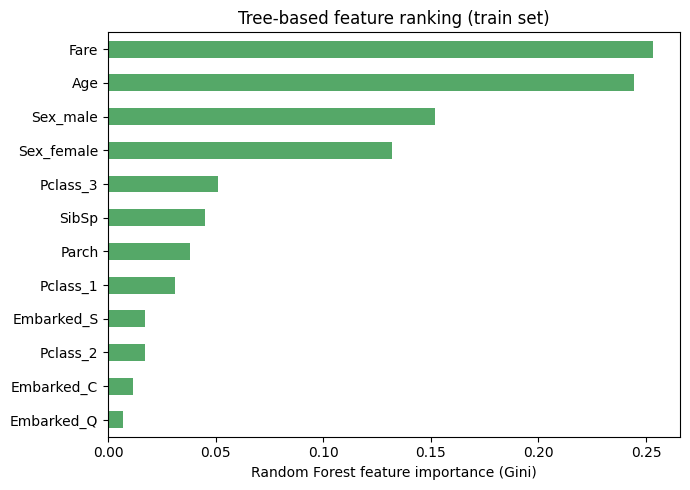

In [13]:
fig, ax = plt.subplots(figsize=(7, 5))
rf_importances.plot(kind="barh", ax=ax, color="#55A868")
ax.invert_yaxis()
ax.set_xlabel("Random Forest feature importance (Gini)")
ax.set_title("Tree-based feature ranking (train set)")
plt.tight_layout()
plt.show()

**Cross-checking the two rankings:** `Sex_male`/`Sex_female` and `Fare` dominate both the mutual-information and tree-based rankings, which is a good sign — two different ranking methods agreeing on the top signal gives more confidence than either alone. `Pclass_3` and `Age` follow. Family-size features (`SibSp`, `Parch`) rank lower by both methods, consistent with their weaker correlation with the target seen in Section 6.

## 9. Summary

- **Leakage-free by construction:** `train_test_split` ran first; every subsequent `SimpleImputer`, `StandardScaler`, `OneHotEncoder`/`TargetEncoder`, and the classifier itself are fit exclusively on `X_train`/`y_train` inside a single `Pipeline`/`ColumnTransformer`. Calling `.predict()` on `X_test` only ever *transforms* it with statistics already learned from training data.
- **Reusability:** `build_preprocessor()` takes any list of numeric/categorical column names and an encoding choice, so this same pipeline structure can be pointed at a Credit Default Risk or Medical Diagnostics dataset by changing three lines (the file path, `numeric_features`, `categorical_features`).
- **Feature importance agreement:** Mutual information and Random Forest importances agree on `Sex` and `Fare` as the strongest predictors, giving converging evidence rather than relying on a single method.
- **Next steps for a real deployment:** cross-validate the encoding choice (one-hot vs. target) and imputation strategy inside the same held-out discipline (e.g., `GridSearchCV` with the `Pipeline` as the estimator, never tuning on the test set), and consider engineering a `Title` feature from `Name` before dropping it.